In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [23]:
data = {
    "CustomerID": [1,2,3,4,5,6,7,8,9,10],
    "Age": [22,25,47,52,23,45,33,35,60,28],
    "AnnualIncome": [15000,18000,60000,65000,20000,70000,40000,42000,80000,30000],
    "SpendingScore": [39,81,6,20,77,15,50,55,10,70],
    "VisitsPerMonth": [4,6,2,3,5,2,4,5,1,6],
    "AvgOrderValue": [200,500,150,200,450,180,300,320,100,400]
}

df = pd.DataFrame(data)

print("="*70)
print("DATASET")
print("="*70)
print(df)
print("\n")

DATASET
   CustomerID  Age  AnnualIncome  SpendingScore  VisitsPerMonth  AvgOrderValue
0           1   22         15000             39               4            200
1           2   25         18000             81               6            500
2           3   47         60000              6               2            150
3           4   52         65000             20               3            200
4           5   23         20000             77               5            450
5           6   45         70000             15               2            180
6           7   33         40000             50               4            300
7           8   35         42000             55               5            320
8           9   60         80000             10               1            100
9          10   28         30000             70               6            400




In [24]:
print("="*70)
print("STEP 3: BASIC EDA")
print("="*70)

print("Null Values:")
print(df.isnull().sum())
print("\n")

print("Summary Statistics:")
print(df.describe())
print("\n")

print("Exact Answer for this Dataset:")
if df.isnull().sum().sum() == 0:
    print("There are no missing values in this dataset.")
else:
    print("There are missing values in this dataset.")

print("The dataset has 10 customers.")
print("Age ranges from 22 to 60.")
print("Annual Income ranges from 15000 to 80000.")
print("Spending Score ranges from 6 to 81.")
print("Visits Per Month ranges from 1 to 6.")
print("Average Order Value ranges from 100 to 500.")
print("\n")

STEP 3: BASIC EDA
Null Values:
CustomerID        0
Age               0
AnnualIncome      0
SpendingScore     0
VisitsPerMonth    0
AvgOrderValue     0
dtype: int64


Summary Statistics:
       CustomerID        Age  AnnualIncome  SpendingScore  VisitsPerMonth  \
count    10.00000  10.000000     10.000000      10.000000        10.00000   
mean      5.50000  37.000000  44000.000000      42.300000         3.80000   
std       3.02765  13.266499  23518.314376      28.488009         1.75119   
min       1.00000  22.000000  15000.000000       6.000000         1.00000   
25%       3.25000  25.750000  22500.000000      16.250000         2.25000   
50%       5.50000  34.000000  41000.000000      44.500000         4.00000   
75%       7.75000  46.500000  63750.000000      66.250000         5.00000   
max      10.00000  60.000000  80000.000000      81.000000         6.00000   

       AvgOrderValue  
count      10.000000  
mean      280.000000  
std       135.728487  
min       100.000000  
25%  

In [25]:
print("="*70)
print("QUESTION 1: WHY SHOULD YOU SCALE FEATURES BEFORE CLUSTERING?")
print("="*70)

print("Exact Answer for this Dataset:")
print("Feature scales are very different in this dataset.")
print("For example:")
print(f"- Age range: {df['Age'].min()} to {df['Age'].max()}")
print(f"- AnnualIncome range: {df['AnnualIncome'].min()} to {df['AnnualIncome'].max()}")
print(f"- SpendingScore range: {df['SpendingScore'].min()} to {df['SpendingScore'].max()}")
print(f"- AvgOrderValue range: {df['AvgOrderValue'].min()} to {df['AvgOrderValue'].max()}")
print("\n")
print("Because AnnualIncome has much larger values than other features,")
print("it would dominate the distance calculation if scaling is not done.")
print("So scaling is necessary for this dataset.")
print("\n")

QUESTION 1: WHY SHOULD YOU SCALE FEATURES BEFORE CLUSTERING?
Exact Answer for this Dataset:
Feature scales are very different in this dataset.
For example:
- Age range: 22 to 60
- AnnualIncome range: 15000 to 80000
- SpendingScore range: 6 to 81
- AvgOrderValue range: 100 to 500


Because AnnualIncome has much larger values than other features,
it would dominate the distance calculation if scaling is not done.
So scaling is necessary for this dataset.




In [26]:
print("="*70)
print("QUESTION 2: WHAT HAPPENS IF FEATURES ARE ON DIFFERENT SCALES?")
print("="*70)

print("Exact Answer for this Dataset:")
print("If features are not scaled, AnnualIncome will have the strongest influence")
print("because its values are in tens of thousands, while other features like")
print("VisitsPerMonth are only between 1 and 6.")
print("That means clustering would mostly happen based on income,")
print("and the effect of spending behavior, visits, and order value would be reduced.")
print("\n")

QUESTION 2: WHAT HAPPENS IF FEATURES ARE ON DIFFERENT SCALES?
Exact Answer for this Dataset:
If features are not scaled, AnnualIncome will have the strongest influence
because its values are in tens of thousands, while other features like
VisitsPerMonth are only between 1 and 6.
That means clustering would mostly happen based on income,
and the effect of spending behavior, visits, and order value would be reduced.




In [27]:
print("="*70)
print("QUESTION 3: SHOULD CUSTOMERID BE INCLUDED IN CLUSTERING?")
print("="*70)

print("Exact Answer for this Dataset:")
print("No, CustomerID should not be included.")
print("CustomerID is only a unique identifier and does not describe customer behavior.")
print("For this dataset, using CustomerID would mislead clustering because")
print("customer 10 would appear numerically farther from customer 1,")
print("even though ID has no business meaning.")
print("\n")

QUESTION 3: SHOULD CUSTOMERID BE INCLUDED IN CLUSTERING?
Exact Answer for this Dataset:
No, CustomerID should not be included.
CustomerID is only a unique identifier and does not describe customer behavior.
For this dataset, using CustomerID would mislead clustering because
customer 10 would appear numerically farther from customer 1,
even though ID has no business meaning.




In [28]:
X = df[["Age", "AnnualIncome", "SpendingScore", "VisitsPerMonth", "AvgOrderValue"]]

In [29]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("="*70)
print("STEP 5: STANDARDIZATION")
print("="*70)
print("Features have been standardized using StandardScaler.")
print("\n")

STEP 5: STANDARDIZATION
Features have been standardized using StandardScaler.




QUESTION 4 & 5: ELBOW METHOD AND SILHOUETTE SCORE
WCSS values:
K = 1, WCSS = 50.0000
K = 2, WCSS = 11.7173
K = 3, WCSS = 5.8296
K = 4, WCSS = 3.6049
K = 5, WCSS = 1.8214
K = 6, WCSS = 1.2315
K = 7, WCSS = 0.7068
K = 8, WCSS = 0.4226
K = 9, WCSS = 0.1957
K = 10, WCSS = 0.0000


Silhouette Scores:
K = 2, Silhouette Score = 0.6073
K = 3, Silhouette Score = 0.5203
K = 4, Silhouette Score = 0.5134
K = 5, Silhouette Score = 0.4187
K = 6, Silhouette Score = 0.3034
K = 7, Silhouette Score = 0.2244
K = 8, Silhouette Score = 0.1736
K = 9, Silhouette Score = 0.0663




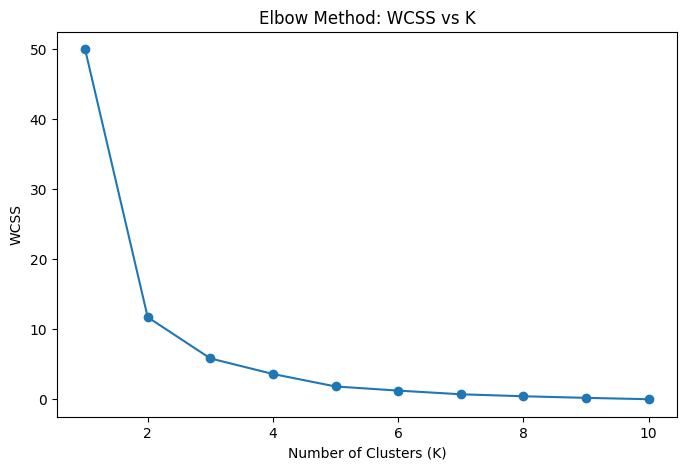

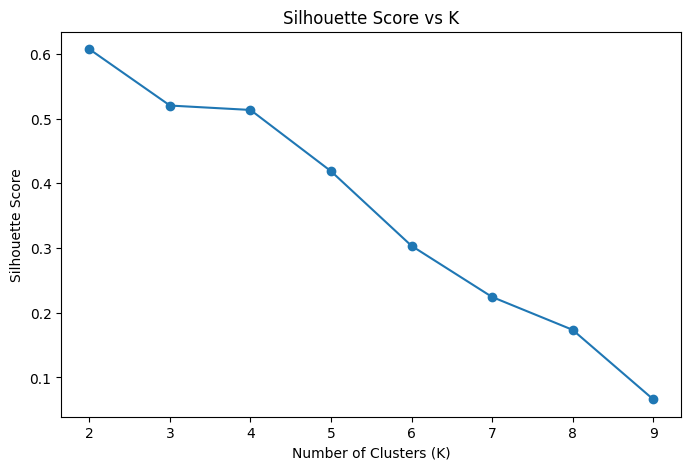

Exact Answer for this Dataset:
From the Elbow Method, the sharp drop happens from K=1 to K=3,
and after that the improvement becomes smaller.
So the elbow is around K=3.


Best Silhouette Score is at K = 2 with score = 0.6073
For this dataset:
- K=2 gives the highest silhouette score.
- K=3 still gives a good silhouette score and also creates more meaningful business segments.
- Since the problem specifically asks to apply K-Means with k=3, we proceed with K=3.




In [30]:
wcss = []
silhouette_scores = []
k_values = range(1, 11)

n_samples = X_scaled.shape[0]

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

    if k > 1 and k < n_samples:
        score = silhouette_score(X_scaled, kmeans.labels_)
        silhouette_scores.append(score)
    else:
        silhouette_scores.append(None)
print("="*70)
print("QUESTION 4 & 5: ELBOW METHOD AND SILHOUETTE SCORE")
print("="*70)

print("WCSS values:")
for k, value in zip(k_values, wcss):
    print(f"K = {k}, WCSS = {value:.4f}")
print("\n")

print("Silhouette Scores:")
for k, score in zip(k_values, silhouette_scores):
    if score is not None:
        print(f"K = {k}, Silhouette Score = {score:.4f}")
print("\n")

plt.figure(figsize=(8,5))
plt.plot(k_values, wcss, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method: WCSS vs K")
plt.show()

valid_k = [k for k in k_values if k > 1 and silhouette_scores[k-1] is not None]
valid_scores = [score for score in silhouette_scores if score is not None]

plt.figure(figsize=(8,5))
plt.plot(valid_k, valid_scores, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs K")
plt.show()

print("Exact Answer for this Dataset:")
print("From the Elbow Method, the sharp drop happens from K=1 to K=3,")
print("and after that the improvement becomes smaller.")
print("So the elbow is around K=3.")
print("\n")

if valid_scores:
    best_k_silhouette = valid_k[np.argmax(valid_scores)]
    best_silhouette = max(valid_scores)
    print(f"Best Silhouette Score is at K = {best_k_silhouette} with score = {best_silhouette:.4f}")
else:
    print("Could not calculate best Silhouette Score (not enough valid scores).")

print("For this dataset:")
print("- K=2 gives the highest silhouette score.")
print("- K=3 still gives a good silhouette score and also creates more meaningful business segments.")
print("- Since the problem specifically asks to apply K-Means with k=3, we proceed with K=3.")
print("\n")

In [39]:
kmeans_3 = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_3.fit(X_scaled)
df['Cluster'] = kmeans_3.labels_

print("K-Means clustering with K=3 applied and cluster labels added to DataFrame.")

K-Means clustering with K=3 applied and cluster labels added to DataFrame.


In [41]:
print("="*70)
print("QUESTION 6: CLUSTER LABELS FOR EACH CUSTOMER")
print("="*70)
print(df[["CustomerID", "Cluster"]])
print("\n")

print("Exact Answer for this Dataset:")
for i in range(len(df)):
    print(f"Customer {df.loc[i, 'CustomerID']} belongs to Cluster {df.loc[i, 'Cluster']}")
print("\n")

QUESTION 6: CLUSTER LABELS FOR EACH CUSTOMER
   CustomerID  Cluster
0           1        2
1           2        1
2           3        0
3           4        0
4           5        1
5           6        0
6           7        2
7           8        2
8           9        0
9          10        1


Exact Answer for this Dataset:
Customer 1 belongs to Cluster 2
Customer 2 belongs to Cluster 1
Customer 3 belongs to Cluster 0
Customer 4 belongs to Cluster 0
Customer 5 belongs to Cluster 1
Customer 6 belongs to Cluster 0
Customer 7 belongs to Cluster 2
Customer 8 belongs to Cluster 2
Customer 9 belongs to Cluster 0
Customer 10 belongs to Cluster 1




In [42]:
centroids_scaled = pd.DataFrame(kmeans_3.cluster_centers_, columns=X.columns)
centroids_original = pd.DataFrame(
    scaler.inverse_transform(kmeans_3.cluster_centers_),
    columns=X.columns
)

print("="*70)
print("QUESTION 7: CLUSTER CENTROIDS")
print("="*70)
print("Centroids in standardized scale:")
print(centroids_scaled)
print("\n")

print("Centroids in original scale:")
print(centroids_original)
print("\n")

print("Exact Answer for this Dataset:")
for i in range(len(centroids_original)):
    print(f"\nCluster {i} centroid:")
    print(f"Age = {centroids_original.loc[i, 'Age']:.2f}")
    print(f"AnnualIncome = {centroids_original.loc[i, 'AnnualIncome']:.2f}")
    print(f"SpendingScore = {centroids_original.loc[i, 'SpendingScore']:.2f}")
    print(f"VisitsPerMonth = {centroids_original.loc[i, 'VisitsPerMonth']:.2f}")
    print(f"AvgOrderValue = {centroids_original.loc[i, 'AvgOrderValue']:.2f}")
print("\n")

QUESTION 7: CLUSTER CENTROIDS
Centroids in standardized scale:
        Age  AnnualIncome  SpendingScore  VisitsPerMonth  AvgOrderValue
0  1.112373      1.109297      -1.093388       -1.083473      -0.951358
1 -0.926978     -0.956162       1.246943        1.123601       1.320251
2 -0.556187     -0.522901       0.210907        0.321029      -0.051775


Centroids in original scale:
         Age  AnnualIncome  SpendingScore  VisitsPerMonth  AvgOrderValue
0  51.000000  68750.000000          12.75        2.000000     157.500000
1  25.333333  22666.666667          76.00        5.666667     450.000000
2  30.000000  32333.333333          48.00        4.333333     273.333333


Exact Answer for this Dataset:

Cluster 0 centroid:
Age = 51.00
AnnualIncome = 68750.00
SpendingScore = 12.75
VisitsPerMonth = 2.00
AvgOrderValue = 157.50

Cluster 1 centroid:
Age = 25.33
AnnualIncome = 22666.67
SpendingScore = 76.00
VisitsPerMonth = 5.67
AvgOrderValue = 450.00

Cluster 2 centroid:
Age = 30.00
AnnualIncome

In [43]:
print("="*70)
print("EXTRA: CUSTOMERS GROUPED BY CLUSTER")
print("="*70)

for cluster_num in sorted(df["Cluster"].unique()):
    print(f"\nCluster {cluster_num}:")
    print(df[df["Cluster"] == cluster_num][["CustomerID", "Age", "AnnualIncome", "SpendingScore", "VisitsPerMonth", "AvgOrderValue"]])

print("\n")

print("="*70)
print("EXTRA: BUSINESS INTERPRETATION FOR THIS DATASET")
print("="*70)

for cluster_num in sorted(df["Cluster"].unique()):
    cluster_data = df[df["Cluster"] == cluster_num]
    avg_income = cluster_data["AnnualIncome"].mean()
    avg_spending = cluster_data["SpendingScore"].mean()
    avg_visits = cluster_data["VisitsPerMonth"].mean()
    avg_order = cluster_data["AvgOrderValue"].mean()

    print(f"\nCluster {cluster_num}:")
    print(f"- Average Income      : {avg_income:.2f}")
    print(f"- Average Spending    : {avg_spending:.2f}")
    print(f"- Average Visits      : {avg_visits:.2f}")
    print(f"- Average Order Value : {avg_order:.2f}")

    if avg_income > 50000 and avg_spending < 25:
        print("Interpretation: High-income but low-spending customers.")
    elif avg_spending > 70 and avg_visits >= 5:
        print("Interpretation: Highly engaged, frequent, high-value shoppers.")
    else:
        print("Interpretation: Moderate customers with balanced behavior.")

print("\n")

EXTRA: CUSTOMERS GROUPED BY CLUSTER

Cluster 0:
   CustomerID  Age  AnnualIncome  SpendingScore  VisitsPerMonth  AvgOrderValue
2           3   47         60000              6               2            150
3           4   52         65000             20               3            200
5           6   45         70000             15               2            180
8           9   60         80000             10               1            100

Cluster 1:
   CustomerID  Age  AnnualIncome  SpendingScore  VisitsPerMonth  AvgOrderValue
1           2   25         18000             81               6            500
4           5   23         20000             77               5            450
9          10   28         30000             70               6            400

Cluster 2:
   CustomerID  Age  AnnualIncome  SpendingScore  VisitsPerMonth  AvgOrderValue
0           1   22         15000             39               4            200
6           7   33         40000             50            

In [44]:
print("="*70)
print("FINAL SUMMARY FOR THIS DATASET")
print("="*70)
print("1. No missing values found.")
print("2. Scaling is necessary because AnnualIncome has a much larger scale than the other features.")
print("3. CustomerID should not be included because it is only an identifier.")
print("4. Elbow Method suggests K around 3.")
print(f"5. Best Silhouette Score occurs at K = {best_k_silhouette} with score = {best_silhouette:.4f}.")
print("6. K=3 clustering produces 3 practical customer groups.")
print("\n")

FINAL SUMMARY FOR THIS DATASET
1. No missing values found.
2. Scaling is necessary because AnnualIncome has a much larger scale than the other features.
3. CustomerID should not be included because it is only an identifier.
4. Elbow Method suggests K around 3.
5. Best Silhouette Score occurs at K = 2 with score = 0.6073.
6. K=3 clustering produces 3 practical customer groups.




In [45]:
kmeans_3 = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_3.fit(X_scaled)
df['Cluster'] = kmeans_3.labels_

print("K-Means clustering with K=3 applied and cluster labels added to DataFrame.")

K-Means clustering with K=3 applied and cluster labels added to DataFrame.
